# [LangGraph](https://langchain-ai.github.io/langgraph/concepts/why-langgraph/)
- LangGraph는 LLM을 사용하여 상태를 유지하고 여러 에이전트를 포함한 애플리케이션을 쉽게 만들 수 있도록 도와줍니다.
- 이 도구는 LangChain의 기능을 확장하여, 복잡한 에이전트 런타임 개발에 필수적인 순환 그래프를 만들고 관리할 수 있는 기능을 추가합니다.
- LangGraph의 핵심 개념에는 그래프 구조, 상태 관리 및 조정이 포함됩니다.

## LangGraph의 핵심 구성요소

-  Node (노드): 실제 작업을 수행하는 단위
    - 질문 분석, 답변 생성, 검색 등의 구체적인 작업
-  Edge (간선): 노드들을 순차적으로 연결
    - 데이터가 흐르는 기본 경로
- Conditional Edge: 조건에 따라 다른 경로로 분기
    - "정보가 충분한가?" 같은 판단 후 YES/NO로 갈라짐
-  State (상태): 모든 노드가 공유하는 데이터 저장소
    - 질문, 수집된 정보, 처리 상태 등을 계속 저장하고 업데이트

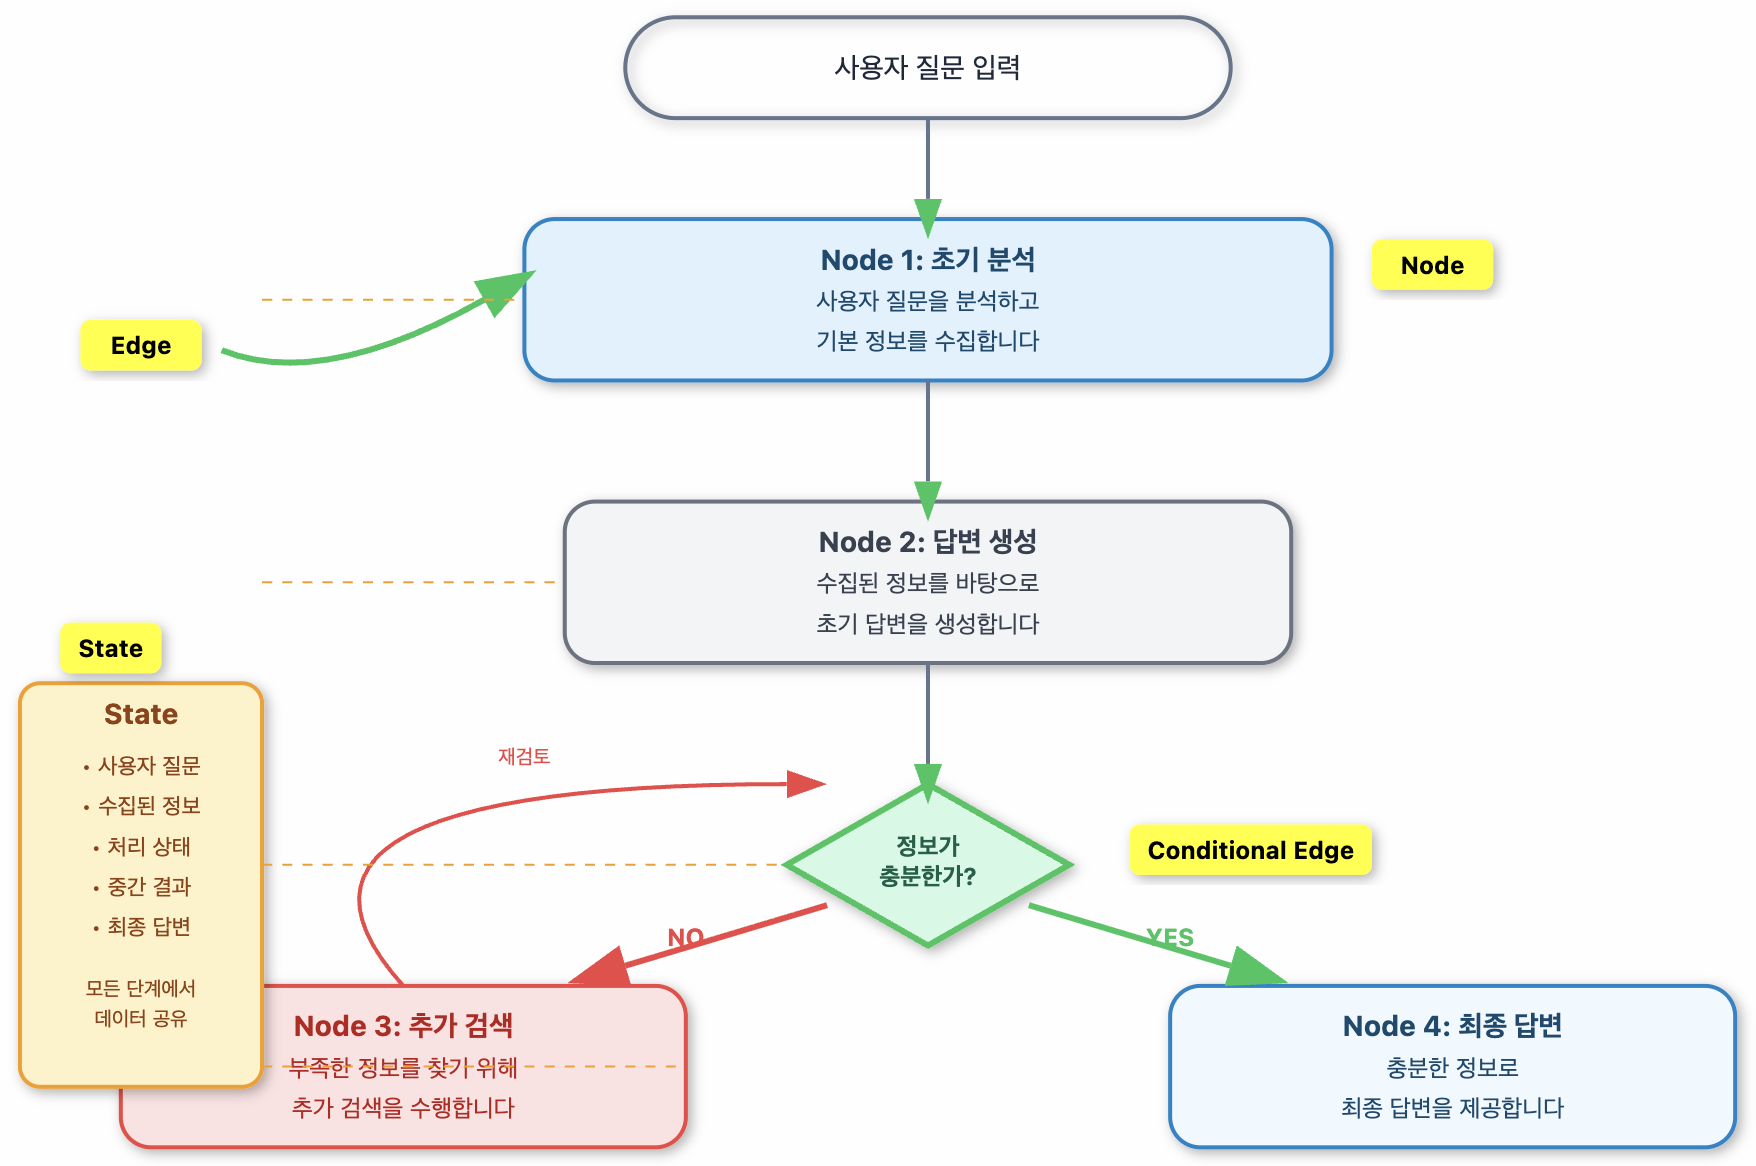

# LangGraph with LLM 예제

## 1단계: 상태(State) 정의
- State: 워크플로우에서 데이터를 저장하는 상태

### add_messages
- `add_messages`는 LangGraph에서 여러 개의 messages(대화 기록)를 하나의 대화 흐름으로 합치기(merge) 위해 사용하는 유틸리티 함수입니다.
- 이 함수는 LangGraph의 상태(state) 관리 시스템에서 채팅 메시지 기반 상태 업데이트를 단순화하는 역할을 합니다.

In [3]:
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict

class BasicState(TypedDict):
    """
    워크플로우에서 사용할 상태를 정의합니다.
    - messages: 대화 메시지들을 저장
    """
    messages: Annotated[list, add_messages]

## 2단계: 노드(Node) 함수 생성

In [4]:
from langchain_ollama.chat_models import ChatOllama 

def chat_node(state: BasicState):
    """
    LLM과 대화하는 노드입니다.
    입력: 현재 상태(메시지들)
    출력: LLM의 응답이 추가된 새로운 상태
    """
    # 모델 생성
    llm = ChatOllama(
        model="gemma3:4b",      # 이미 다운로드된 모델명 
        temperature=0.9,
        top_p=0.9,
        num_predict=512,
        keep_alive="10m"        # 로컬PC에서 모델이 메모리에 유지되는 시간 
    )
    
    print(f"사용자 질문: {state['messages'][-1].content}")
    
    # LLM에게 질문하고 답변 받기
    response = llm.invoke(state["messages"])
    
    print(f"AI 응답: {response.content}")
    
    # 새로운 메시지를 상태에 추가해서 반환
    return {"messages": [response]}

## 3단계: 그래프 구성하기

In [5]:
from langgraph.graph import StateGraph

def create_simple_chat_graph():
    """
    간단한 채팅 그래프를 만듭니다.
    """
    # StateGraph 객체 생성 (상태 타입을 지정)
    workflow = StateGraph(BasicState)
    
    # 노드 추가 (이름, 함수)
    workflow.add_node("chat", chat_node)
    
    # 시작점과 엣지를 올바르게 설정
    workflow.set_entry_point("chat")  # 시작점 설정
    workflow.set_finish_point("chat")  # 종료점 설정 
    
    # 그래프 컴파일 (실행 가능한 형태로 변환)
    return workflow.compile()

## 4단계: 그래프 확인

```
             시작
               |
               v
             chat
               |
               v
             종료
```

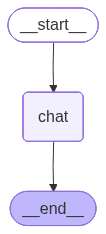

In [6]:
from IPython.display import Image, display

try:
    graph = create_simple_chat_graph()
    
    display(
        Image(
            graph.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

## 5단계: 테스트

In [7]:
from langchain_core.messages import HumanMessage

# 그래프 생성
chat_graph = create_simple_chat_graph()

# 그래프 실행
question = "안녕하세요! 파이썬이 무엇인지 간단히 설명해주세요."
result = chat_graph.invoke({
    "messages": [HumanMessage(content=question)]
})

사용자 질문: 안녕하세요! 파이썬이 무엇인지 간단히 설명해주세요.
AI 응답: 안녕하세요! 파이썬에 대해 간단하게 설명해 드릴게요.

**파이썬이란 무엇일까요?**

파이썬은 **사람이 읽기 쉬운 문법**을 가진 **고급 프로그래밍 언어**입니다. 마치 우리가 일상적으로 사용하는 한국어와 비슷한 방식으로 코드를 작성할 수 있다는 장점이 있죠. 

**파이썬의 특징:**

*   **쉬운 문법:** 다른 프로그래밍 언어에 비해 문법이 단순하고 직관적이라 배우기 쉽습니다.
*   **다양한 활용:** 웹 개발, 데이터 분석, 인공지능(AI), 머신러닝, 자동화 스크립트 등 다양한 분야에서 사용됩니다.
*   **풍부한 라이브러리:** 다양한 기능을 제공하는 방대한 라이브러리(모듈)가 있어서, 개발자가 직접 코드를 많이 작성하지 않아도 다양한 작업을 수행할 수 있습니다.
*   **크로스 플랫폼:** Windows, macOS, Linux 등 다양한 운영체제에서 실행됩니다.

**파이썬으로 무엇을 할 수 있을까요?**

*   **웹 사이트 만들기:** Django, Flask 등의 프레임워크를 사용하여 웹 사이트를 만들 수 있습니다.
*   **데이터 분석:** Pandas, NumPy 등의 라이브러리를 사용하여 데이터를 분석하고 시각화할 수 있습니다.
*   **인공지능 개발:** TensorFlow, PyTorch 등의 라이브러리를 사용하여 딥러닝 모델을 만들고 학습시킬 수 있습니다.
*   **자동화 스크립트 작성:** 반복적인 작업을 자동화하는 스크립트를 작성할 수 있습니다.

**쉽게 시작하기:**

파이썬은 배우기 쉽고 활용 범위가 넓기 때문에, 프로그래밍을 처음 시작하는 사람들에게 아주 좋은 선택입니다. 파이썬 공식 웹사이트([https://www.python.org/](https://www.python.org/))에서 파이썬 설치 방법과 튜토리얼을 찾아보세요.

혹시 더 궁금한 점이 있다면 언제든지 질문해주세요!


In [8]:
print(result['messages'][-1].content)

안녕하세요! 파이썬에 대해 간단하게 설명해 드릴게요.

**파이썬이란 무엇일까요?**

파이썬은 **사람이 읽기 쉬운 문법**을 가진 **고급 프로그래밍 언어**입니다. 마치 우리가 일상적으로 사용하는 한국어와 비슷한 방식으로 코드를 작성할 수 있다는 장점이 있죠. 

**파이썬의 특징:**

*   **쉬운 문법:** 다른 프로그래밍 언어에 비해 문법이 단순하고 직관적이라 배우기 쉽습니다.
*   **다양한 활용:** 웹 개발, 데이터 분석, 인공지능(AI), 머신러닝, 자동화 스크립트 등 다양한 분야에서 사용됩니다.
*   **풍부한 라이브러리:** 다양한 기능을 제공하는 방대한 라이브러리(모듈)가 있어서, 개발자가 직접 코드를 많이 작성하지 않아도 다양한 작업을 수행할 수 있습니다.
*   **크로스 플랫폼:** Windows, macOS, Linux 등 다양한 운영체제에서 실행됩니다.

**파이썬으로 무엇을 할 수 있을까요?**

*   **웹 사이트 만들기:** Django, Flask 등의 프레임워크를 사용하여 웹 사이트를 만들 수 있습니다.
*   **데이터 분석:** Pandas, NumPy 등의 라이브러리를 사용하여 데이터를 분석하고 시각화할 수 있습니다.
*   **인공지능 개발:** TensorFlow, PyTorch 등의 라이브러리를 사용하여 딥러닝 모델을 만들고 학습시킬 수 있습니다.
*   **자동화 스크립트 작성:** 반복적인 작업을 자동화하는 스크립트를 작성할 수 있습니다.

**쉽게 시작하기:**

파이썬은 배우기 쉽고 활용 범위가 넓기 때문에, 프로그래밍을 처음 시작하는 사람들에게 아주 좋은 선택입니다. 파이썬 공식 웹사이트([https://www.python.org/](https://www.python.org/))에서 파이썬 설치 방법과 튜토리얼을 찾아보세요.

혹시 더 궁금한 점이 있다면 언제든지 질문해주세요!


## Langsmith에서 확인

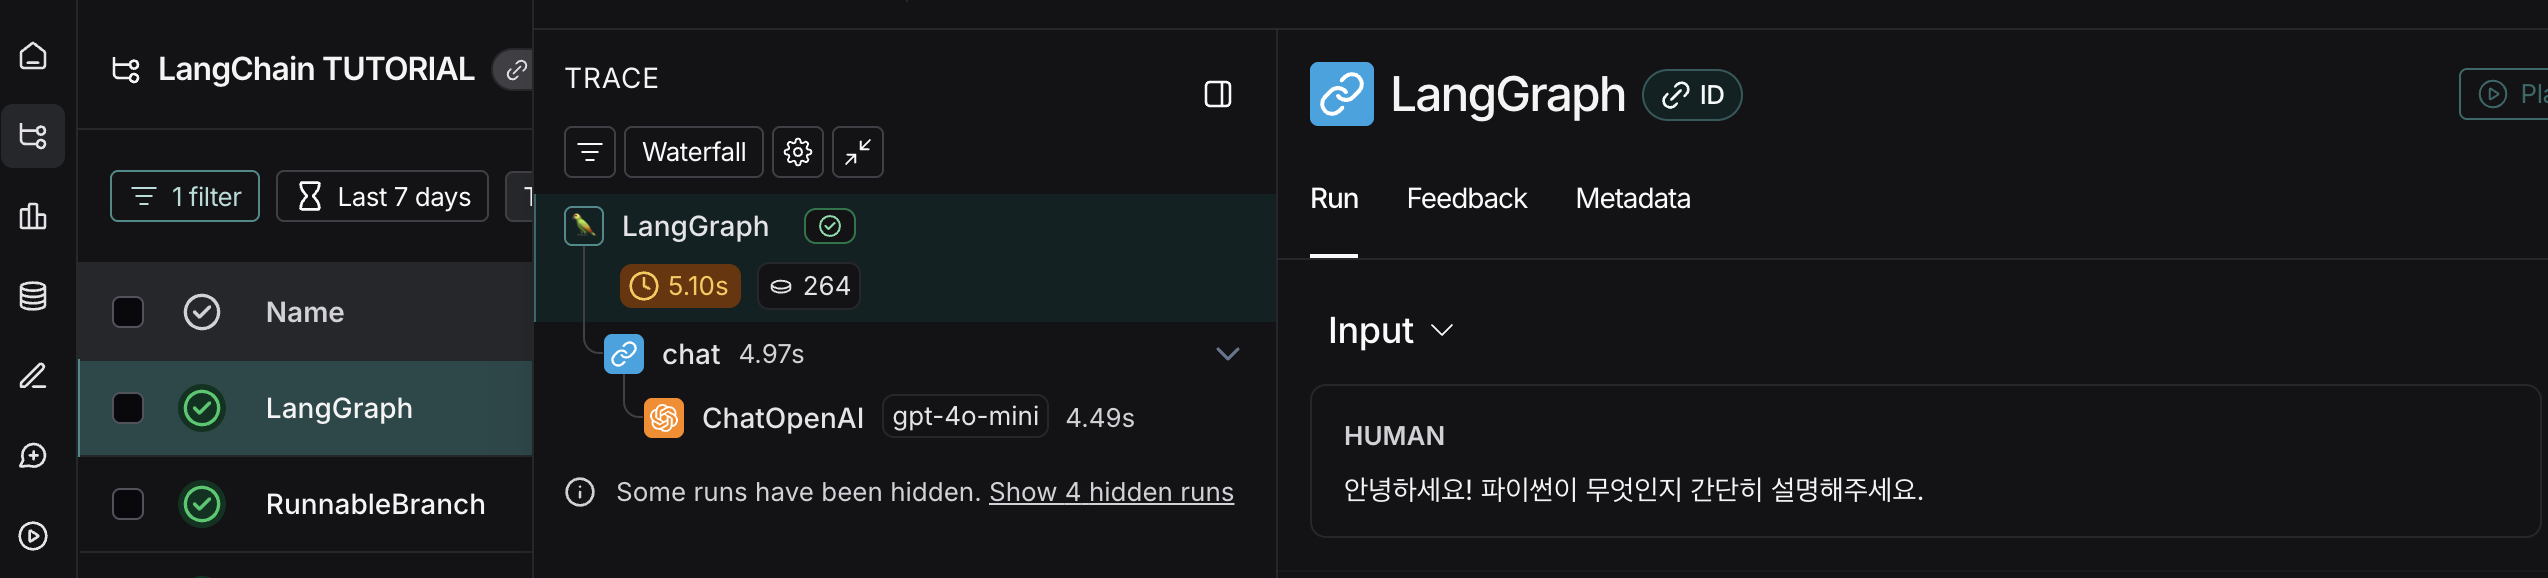